In [1]:
import os
import pandas as pd

# Directory containing the data files
data_dir = "alpha_vantage_data"

# List all CSV files in the directory
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Load and concatenate all CSV files into one DataFrame
df = pd.concat([pd.read_csv(os.path.join(data_dir, f)) for f in files], ignore_index=True)

# df

In [2]:
import numpy as np

# Calculate log returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)

In [3]:
df.describe()

,open,high,low,close,volume,log_return
count,148304.000000,148304.000000,148304.000000,148304.000000,1.483040e+05,148304.000000
mean,188.868258,188.927092,188.808550,188.868354,1.228049e+04,-0.000001
std,22.622569,22.628825,22.615777,22.622388,1.091321e+05,0.002362
min,139.618900,150.446000,139.618900,149.484200,1.000000e+00,-0.303360
25%,171.017000,171.075300,170.978200,171.026700,7.600000e+01,-0.000293
50%,183.210000,183.277200,183.148000,183.215900,3.021000e+03,0.000000
75%,209.101600,209.160300,209.070850,209.101600,6.278000e+03,0.000285
max,236.135400,236.499300,235.928200,236.157300,1.200030e+07,0.340371


<Axes: >

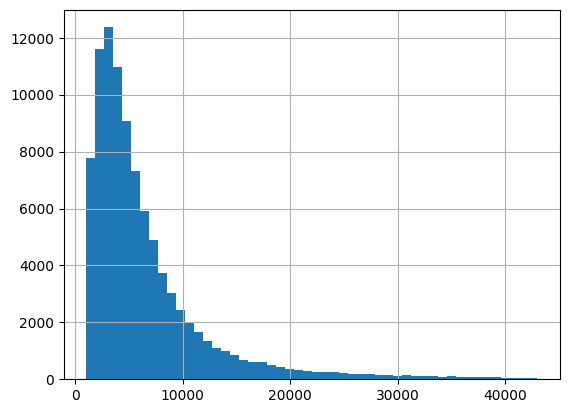

In [4]:
# Filter for open trading hours (e.g., 09:30 to 16:00)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_trading = df[df['timestamp'].dt.time.between(pd.to_datetime('09:30').time(), pd.to_datetime('16:00').time())].sort_values('timestamp')

df_trading.head()
# Plot a histogram of the 'volume' column after removing outliers (e.g., outside 1st and 99th percentiles)
lower = df_trading['volume'].quantile(0.02)
upper = df_trading['volume'].quantile(0.98)
vol_no_outliers = df_trading[(df_trading['volume'] >= lower) & (df_trading['volume'] <= upper)]['volume']
vol_no_outliers.hist(bins=50)


In [5]:
# Bin the volume data into 8 even categories (quantiles)
vol_bins = pd.qcut(vol_no_outliers, 8, labels=[f'Q{i+1}' for i in range(8)])

# Show the count of samples in each bin
print(vol_bins.value_counts().sort_index())

df_trading.loc[vol_no_outliers.index, 'volume_category'] = vol_bins
df_trading.head()

volume
Q1    11779
Q2    11757
Q3    11768
Q4    11764
Q5    11766
Q6    11760
Q7    11762
Q8    11765
Name: count, dtype: int64


,timestamp,open,high,low,close,volume,log_return,volume_category
59792,2024-01-02 09:30:00,155.0549,155.4929,155.0549,155.2834,88110,0.000736,NaN
59791,2024-01-02 09:31:00,155.2263,155.2263,154.9882,155.1691,11952,0.000000,Q8
59790,2024-01-02 09:32:00,155.1596,155.2263,155.1215,155.1691,7685,0.000337,Q6
59789,2024-01-02 09:33:00,155.1406,155.1406,155.0358,155.1168,7479,-0.000337,Q6
59788,2024-01-02 09:34:00,155.1120,155.1787,155.0787,155.1691,4440,0.000491,Q4


<Axes: >

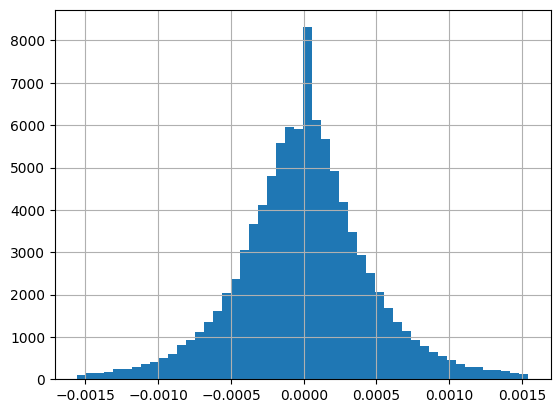

In [6]:
lower = df_trading['log_return'].quantile(0.01)
upper = df_trading['log_return'].quantile(0.99)
log_no_outliers = df_trading[(df_trading['log_return'] >= lower) & (df_trading['log_return'] <= upper)]['log_return']
log_no_outliers.hist(bins=50)

In [7]:
ret_bins = pd.qcut(vol_no_outliers, 8, labels=[f'R{i+1}' for i in range(8)])

# Show the count of samples in each bin
print(ret_bins.value_counts().sort_index())

df_trading.loc[log_no_outliers.index, 'return_cat'] = ret_bins
df_trading.head()

volume
R1    11779
R2    11757
R3    11768
R4    11764
R5    11766
R6    11760
R7    11762
R8    11765
Name: count, dtype: int64


,timestamp,open,high,low,close,volume,log_return,volume_category,return_cat
59792,2024-01-02 09:30:00,155.0549,155.4929,155.0549,155.2834,88110,0.000736,NaN,NaN
59791,2024-01-02 09:31:00,155.2263,155.2263,154.9882,155.1691,11952,0.000000,Q8,R8
59790,2024-01-02 09:32:00,155.1596,155.2263,155.1215,155.1691,7685,0.000337,Q6,R6
59789,2024-01-02 09:33:00,155.1406,155.1406,155.0358,155.1168,7479,-0.000337,Q6,R6
59788,2024-01-02 09:34:00,155.1120,155.1787,155.0787,155.1691,4440,0.000491,Q4,R4


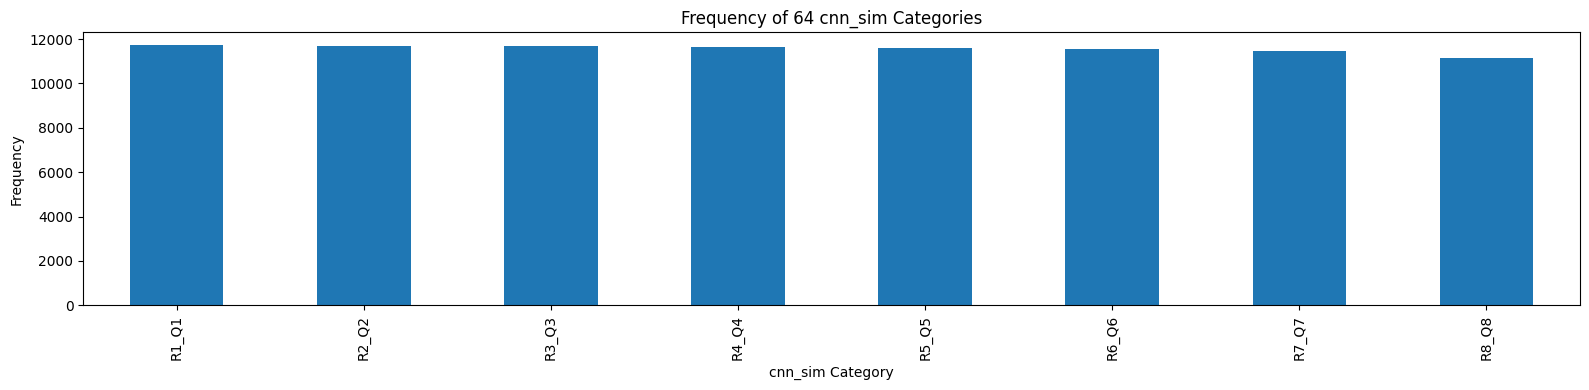

In [8]:
df_trading = df_trading.dropna()
df_trading['cnn_sim'] = df_trading['return_cat'].astype(str) + '_' + df_trading['volume_category'].astype(str)
df_trading['cnn_sim'] = df_trading['cnn_sim'].astype('category')

import matplotlib.pyplot as plt

df_trading['cnn_sim'].value_counts().sort_index().plot(kind='bar', figsize=(16, 4))
plt.xlabel('cnn_sim Category')
plt.ylabel('Frequency')
plt.title('Frequency of 64 cnn_sim Categories')
plt.tight_layout()
plt.show()

In [9]:
df_trading

,timestamp,open,high,low,close,volume,log_return,volume_category,return_cat,cnn_sim
59791,2024-01-02 09:31:00,155.2263,155.2263,154.9882,155.1691,11952,0.000000,Q8,R8,R8_Q8
59790,2024-01-02 09:32:00,155.1596,155.2263,155.1215,155.1691,7685,0.000337,Q6,R6,R6_Q6
59789,2024-01-02 09:33:00,155.1406,155.1406,155.0358,155.1168,7479,-0.000337,Q6,R6,R6_Q6
59788,2024-01-02 09:34:00,155.1120,155.1787,155.0787,155.1691,4440,0.000491,Q4,R4,R4_Q4
59787,2024-01-02 09:35:00,155.0739,155.1311,154.9787,155.0930,8446,0.000123,Q7,R7,R7_Q7
...,...,...,...,...,...,...,...,...,...,...
124745,2024-12-31 15:54:00,216.6926,216.8752,216.6926,216.7469,16399,0.001230,Q8,R8,R8_Q8
124744,2024-12-31 15:55:00,216.6778,216.6877,216.3522,216.4805,30575,-0.001162,Q8,R8,R8_Q8
124743,2024-12-31 15:56:00,216.4854,216.8150,216.4509,216.7321,35182,-0.001024,Q8,R8,R8_Q8
124742,2024-12-31 15:57:00,216.6680,216.9541,216.6285,216.9541,25000,0.000705,Q8,R8,R8_Q8


In [10]:
# Split df_trading into validation and test sets (e.g., 80% validation, 20% test)
val_size = int(len(df_trading) * 0.8)
df_train = df_trading.iloc[:val_size]
df_test = df_trading.iloc[val_size:]

print(f"Training set size: {len(df_train)}")
print(f"Test set size: {len(df_test)}")

Training set size: 74009
Test set size: 18503


In [11]:
with open('to_words.txt', 'w') as f:
    for entry in df_train['cnn_sim']:
        f.write(f"{entry}\n")

In [12]:
vocab = [f"R{i}_Q{j}" for i in range(1, 9) for j in range(1, 9)]
print(vocab)

['R1_Q1', 'R1_Q2', 'R1_Q3', 'R1_Q4', 'R1_Q5', 'R1_Q6', 'R1_Q7', 'R1_Q8', 'R2_Q1', 'R2_Q2', 'R2_Q3', 'R2_Q4', 'R2_Q5', 'R2_Q6', 'R2_Q7', 'R2_Q8', 'R3_Q1', 'R3_Q2', 'R3_Q3', 'R3_Q4', 'R3_Q5', 'R3_Q6', 'R3_Q7', 'R3_Q8', 'R4_Q1', 'R4_Q2', 'R4_Q3', 'R4_Q4', 'R4_Q5', 'R4_Q6', 'R4_Q7', 'R4_Q8', 'R5_Q1', 'R5_Q2', 'R5_Q3', 'R5_Q4', 'R5_Q5', 'R5_Q6', 'R5_Q7', 'R5_Q8', 'R6_Q1', 'R6_Q2', 'R6_Q3', 'R6_Q4', 'R6_Q5', 'R6_Q6', 'R6_Q7', 'R6_Q8', 'R7_Q1', 'R7_Q2', 'R7_Q3', 'R7_Q4', 'R7_Q5', 'R7_Q6', 'R7_Q7', 'R7_Q8', 'R8_Q1', 'R8_Q2', 'R8_Q3', 'R8_Q4', 'R8_Q5', 'R8_Q6', 'R8_Q7', 'R8_Q8']


see `model.py`

In [13]:
# For each row in df_test, create a list of the 255 previous cnn_sim values (excluding the current row)
cnn_sim_sequences = []
cnn_sim_values = df_test['cnn_sim'].tolist()
for i in range(len(cnn_sim_values)):
    start_idx = max(0, i - 255)
    seq = cnn_sim_values[start_idx:i]
    # If less than 255, pad at the beginning with None (or choose a special token if needed)
    seq = [None] * (255 - len(seq)) + seq
    cnn_sim_sequences.append(seq)

# Example: first sequence
print(cnn_sim_sequences[0])  # Should be all None
print(cnn_sim_sequences[255])  # Should have 255 actual previous values

[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, Non

In [ ]:
import torch

# Load your custom model architecture and utility functions
from single_shot_transformer.model import TransformerModel, encode, decode, device, block_size  # adjust imports as needed

# Initialize the model
transformer_model = TransformerModel()

# Load the fine-tuned model weights
transformer_model.load_state_dict(torch.load("fin_transformer_model.pth", map_location=device))
transformer_model.eval()

# Generate predictions for each sequence in cnn_sim_sequences
predicted_classes = []
for seq in cnn_sim_sequences:
    if None in seq:
        predicted_classes.append(None)
        continue
    input_ids = encode(seq)
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0)
    output = decode(transformer_model.generate(input_ids, max_new_tokens=1)[0].tolist())[-1]
    predicted_classes.append(output)

# Add predictions to df_test
df_test = df_test.copy()
df_test['cnn_sim_pred'] = predicted_classes

In [15]:
df_test

,timestamp,open,high,low,close,volume,log_return,volume_category,return_cat,cnn_sim,cnn_sim_pred
67072,2024-10-17 12:32:00,227.8189,227.8532,227.7993,227.8091,1738,0.000301,Q1,R1,R1_Q1,None
67071,2024-10-17 12:33:00,227.7895,227.7895,227.7406,227.7406,3172,-0.000172,Q3,R3,R3_Q3,None
67070,2024-10-17 12:34:00,227.7602,227.7798,227.7210,227.7798,2135,-0.000043,Q1,R1,R1_Q1,None
67069,2024-10-17 12:35:00,227.8140,227.8189,227.7700,227.7895,2691,0.000150,Q2,R2,R2_Q2,None
67068,2024-10-17 12:36:00,227.7993,227.8385,227.7553,227.7553,2981,-0.000451,Q3,R3,R3_Q3,None
...,...,...,...,...,...,...,...,...,...,...,...
124745,2024-12-31 15:54:00,216.6926,216.8752,216.6926,216.7469,16399,0.001230,Q8,R8,R8_Q8,R8_Q8
124744,2024-12-31 15:55:00,216.6778,216.6877,216.3522,216.4805,30575,-0.001162,Q8,R8,R8_Q8,R7_Q7
124743,2024-12-31 15:56:00,216.4854,216.8150,216.4509,216.7321,35182,-0.001024,Q8,R8,R8_Q8,R8_Q8
124742,2024-12-31 15:57:00,216.6680,216.9541,216.6285,216.9541,25000,0.000705,Q8,R8,R8_Q8,R8_Q8


In [16]:
# Absolute accuracy (exact match)
mask = df_test['cnn_sim_pred'].notnull()
absolute_accuracy = (df_test.loc[mask, 'cnn_sim'] == df_test.loc[mask, 'cnn_sim_pred']).mean()
print(f"Absolute accuracy (64-class): {absolute_accuracy:.4f}")

# Collapse to 3 classes: use only the 'R' part (return_cat) from cnn_sim and cnn_sim_pred
def get_return_class(label):
    if pd.isnull(label):
        return None
    return label.split('_')[0]

df_test['cnn_sim_true_r'] = df_test['cnn_sim'].apply(get_return_class)
df_test['cnn_sim_pred_r'] = df_test['cnn_sim_pred'].apply(get_return_class)

mask_r = df_test['cnn_sim_pred_r'].notnull()
# Map R1-R8 to 3 classes: R1-R2 -> 'low', R3-R6 -> 'mid', R7-R8 -> 'high'
def collapse_r(r):
    if r in ['R1', 'R2']:
        return 'low'
    elif r in ['R3', 'R4', 'R5', 'R6']:
        return 'mid'
    elif r in ['R7', 'R8']:
        return 'high'
    return None

df_test['cnn_sim_true_r3'] = df_test['cnn_sim_true_r'].apply(collapse_r)
df_test['cnn_sim_pred_r3'] = df_test['cnn_sim_pred_r'].apply(collapse_r)

mask_r3 = df_test['cnn_sim_pred_r3'].notnull()
accuracy_r3 = (df_test.loc[mask_r3, 'cnn_sim_true_r3'] == df_test.loc[mask_r3, 'cnn_sim_pred_r3']).mean()
print(f"Collapsed 3-class accuracy (return_cat): {accuracy_r3:.4f}")

# Collapse to 2 classes: 'low' (R1-R4), 'high' (R5-R8)
def collapse_r2(r):
    if r in ['R1', 'R2', 'R3', 'R4']:
        return 'low'
    elif r in ['R5', 'R6', 'R7', 'R8']:
        return 'high'
    return None

df_test['cnn_sim_true_r2'] = df_test['cnn_sim_true_r'].apply(collapse_r2)
df_test['cnn_sim_pred_r2'] = df_test['cnn_sim_pred_r'].apply(collapse_r2)

mask_r2 = df_test['cnn_sim_pred_r2'].notnull()
accuracy_r2 = (df_test.loc[mask_r2, 'cnn_sim_true_r2'] == df_test.loc[mask_r2, 'cnn_sim_pred_r2']).mean()
print(f"Collapsed 2-class accuracy (return_cat): {accuracy_r2:.4f}")

Absolute accuracy (64-class): 0.2035
Collapsed 3-class accuracy (return_cat): 0.4832
Collapsed 2-class accuracy (return_cat): 0.6527


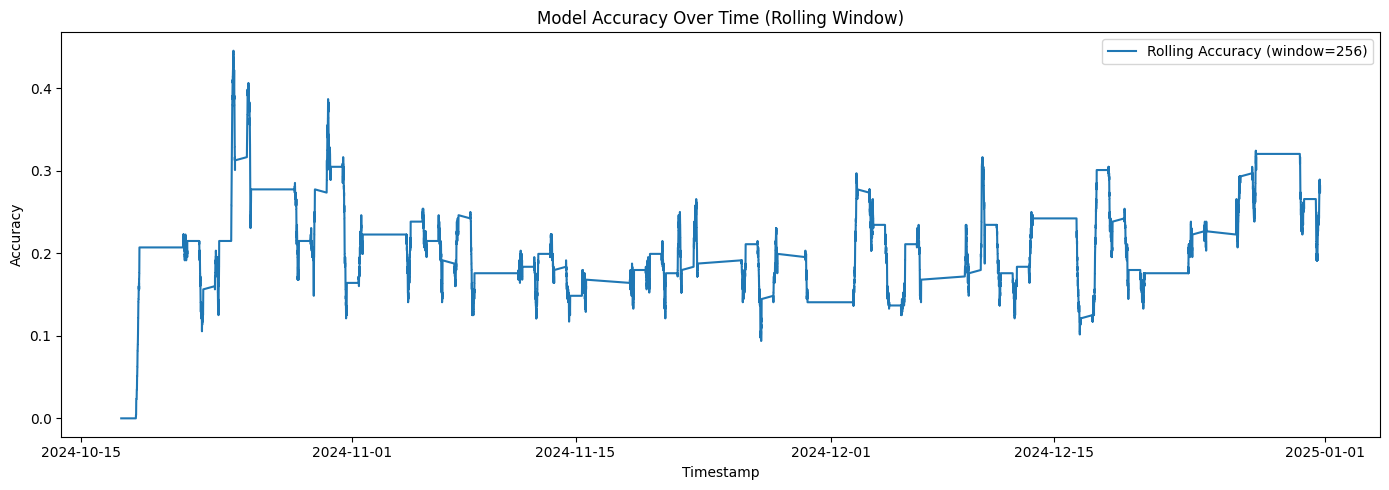

In [17]:
import matplotlib.pyplot as plt

# Ensure the DataFrame is sorted by timestamp
df_test_sorted = df_test.sort_values('timestamp')

# Compute rolling accuracy (window=500 for smoothing, adjust as needed)
window_size = 256
rolling_acc = (df_test_sorted['cnn_sim'] == df_test_sorted['cnn_sim_pred']).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_test_sorted['timestamp'], rolling_acc, label=f'Rolling Accuracy (window={window_size})')
plt.xlabel('Timestamp')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Time (Rolling Window)')
plt.legend()
plt.tight_layout()
plt.show()

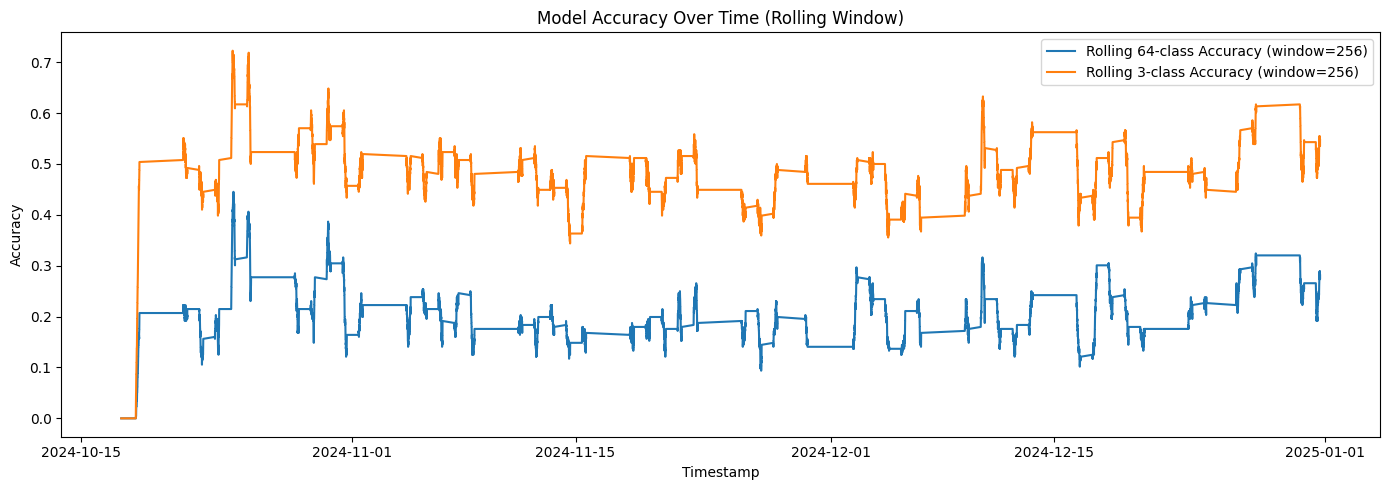

In [18]:
# Compute rolling 3-class accuracy (window=window_size)
rolling_acc_r3 = (df_test_sorted['cnn_sim_true_r3'] == df_test_sorted['cnn_sim_pred_r3']).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_test_sorted['timestamp'], rolling_acc, label=f'Rolling 64-class Accuracy (window={window_size})')
plt.plot(df_test_sorted['timestamp'], rolling_acc_r3, label=f'Rolling 3-class Accuracy (window={window_size})')
plt.xlabel('Timestamp')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Time (Rolling Window)')
plt.legend()
plt.tight_layout()
plt.show()

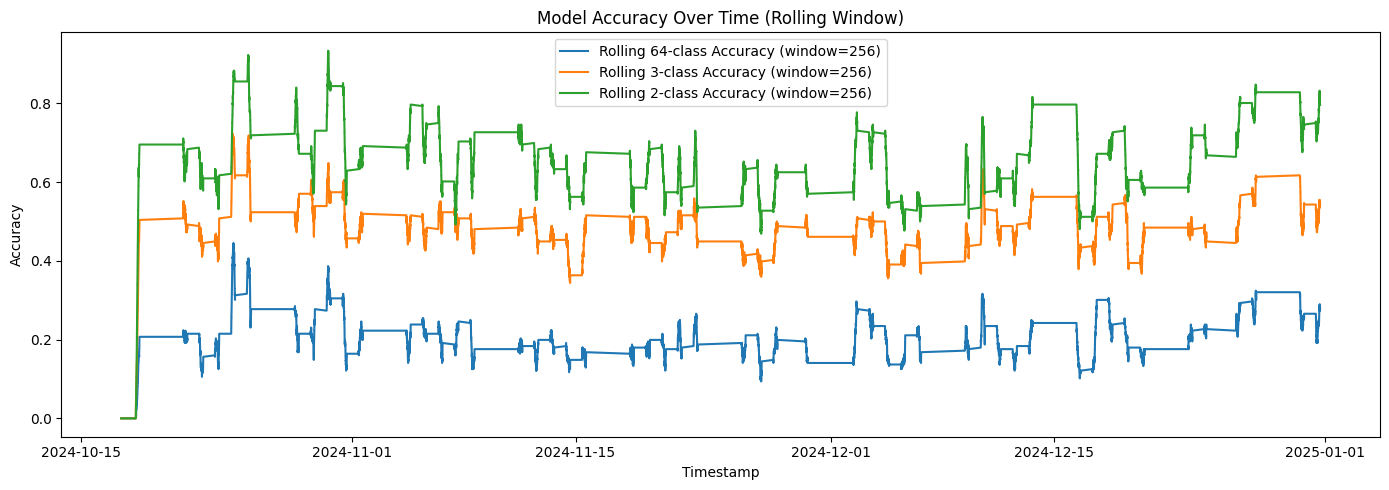

In [19]:
# Compute rolling 2-class accuracy (window=window_size)
rolling_acc_r2 = (df_test_sorted['cnn_sim_true_r2'] == df_test_sorted['cnn_sim_pred_r2']).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_test_sorted['timestamp'], rolling_acc, label=f'Rolling 64-class Accuracy (window={window_size})')
plt.plot(df_test_sorted['timestamp'], rolling_acc_r3, label=f'Rolling 3-class Accuracy (window={window_size})')
plt.plot(df_test_sorted['timestamp'], rolling_acc_r2, label=f'Rolling 2-class Accuracy (window={window_size})')
plt.xlabel('Timestamp')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Time (Rolling Window)')
plt.legend()
plt.tight_layout()
plt.show()

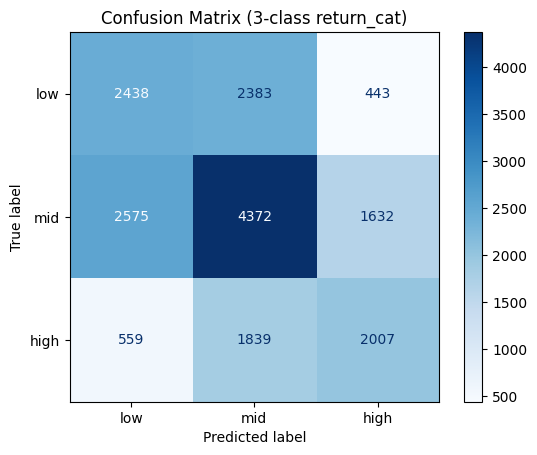

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Only use rows where predictions are not null
mask_r3 = df_test['cnn_sim_pred_r3'].notnull()
y_true = df_test.loc[mask_r3, 'cnn_sim_true_r3']
y_pred = df_test.loc[mask_r3, 'cnn_sim_pred_r3']

cm = confusion_matrix(y_true, y_pred, labels=['low', 'mid', 'high'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'mid', 'high'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (3-class return_cat)')
plt.show()

In [21]:
# Show the distribution of true 3-class labels in df_test as percentages
df_test['cnn_sim_true_r3'].value_counts(normalize=True) * 100

cnn_sim_true_r3
mid     47.013998
low     28.984489
high    24.001513
Name: proportion, dtype: float64